<a href="https://colab.research.google.com/github/lakmg2007/SCALAR_LEARNINGS/blob/main/YouTube.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('/content/youtube_shorts_performance_dataset.csv')
df.head()

,video_id,title,duration_sec,hashtags_count,views,likes,comments,shares,upload_hour,category
0,vid_1000,Short Video #0,43,9,198775,21933,3228,400,8,Tech
1,vid_1001,Short Video #1,56,2,290336,20063,3719,1942,16,Comedy
2,vid_1002,Short Video #2,33,6,264206,37032,3228,1817,7,Food
3,vid_1003,Short Video #3,19,9,85076,27269,2371,980,1,Lifestyle
4,vid_1004,Short Video #4,47,8,90780,8041,2891,1109,23,Tech


In [4]:
print('Dataset Shape:', df.shape)
print('Column Names:')
print(df.columns.tolist())
print('Data Types:')
print(df.dtypes)

Dataset Shape: (300, 10)
Column Names:
['video_id', 'title', 'duration_sec', 'hashtags_count', 'views', 'likes', 'comments', 'shares', 'upload_hour', 'category']
Data Types:
video_id          object
title             object
duration_sec       int64
hashtags_count     int64
views              int64
likes              int64
comments           int64
shares             int64
upload_hour        int64
category          object
dtype: object


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   video_id        300 non-null    object
 1   title           300 non-null    object
 2   duration_sec    300 non-null    int64 
 3   hashtags_count  300 non-null    int64 
 4   views           300 non-null    int64 
 5   likes           300 non-null    int64 
 6   comments        300 non-null    int64 
 7   shares          300 non-null    int64 
 8   upload_hour     300 non-null    int64 
 9   category        300 non-null    object
dtypes: int64(7), object(3)
memory usage: 23.6+ KB


In [6]:
df.describe(include='all')

,video_id,title,duration_sec,hashtags_count,views,likes,comments,shares,upload_hour,category
count,300,300,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300
unique,300,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
top,vid_1299,Short Video #299,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Food
freq,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,57
mean,NaN,NaN,31.730000,4.343333,245058.166667,23063.126667,2638.296667,999.576667,11.543333,NaN
std,NaN,NaN,16.042912,2.956562,141338.982093,14597.458220,1416.827287,564.410105,6.814414,NaN
min,NaN,NaN,5.000000,0.000000,1404.000000,109.000000,40.000000,2.000000,0.000000,NaN
25%,NaN,NaN,18.000000,2.000000,129620.500000,10342.000000,1445.750000,516.250000,6.000000,NaN
50%,NaN,NaN,32.000000,4.000000,255962.000000,21779.500000,2863.500000,988.000000,12.000000,NaN
75%,NaN,NaN,45.000000,7.000000,356805.000000,36706.500000,3761.000000,1463.750000,17.000000,NaN


In [8]:
missing_values = df.isnull().sum()
duplicates = df.duplicated().sum()

print('Missing Values:')
print(missing_values)
print('Duplicate Rows:', duplicates)

Missing Values:
video_id          0
title             0
duration_sec      0
hashtags_count    0
views             0
likes             0
comments          0
shares            0
upload_hour       0
category          0
dtype: int64
Duplicate Rows: 0


In [9]:
df_clean = df.copy()

# Drop identifier columns for modelling
columns_to_drop = ['video_id', 'title']
df_clean = df_clean.drop(columns=columns_to_drop)

df_clean.head()

,duration_sec,hashtags_count,views,likes,comments,shares,upload_hour,category
0,43,9,198775,21933,3228,400,8,Tech
1,56,2,290336,20063,3719,1942,16,Comedy
2,33,6,264206,37032,3228,1817,7,Food
3,19,9,85076,27269,2371,980,1,Lifestyle
4,47,8,90780,8041,2891,1109,23,Tech


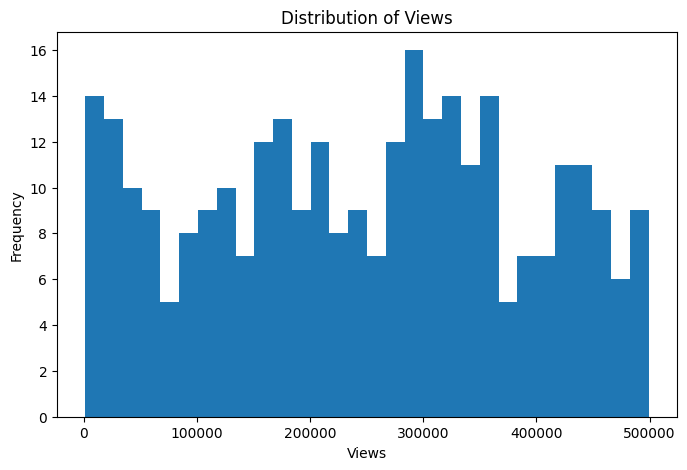

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(df_clean['views'], bins=30)
plt.xlabel('Views')
plt.ylabel('Frequency')
plt.title('Distribution of Views')
plt.show()

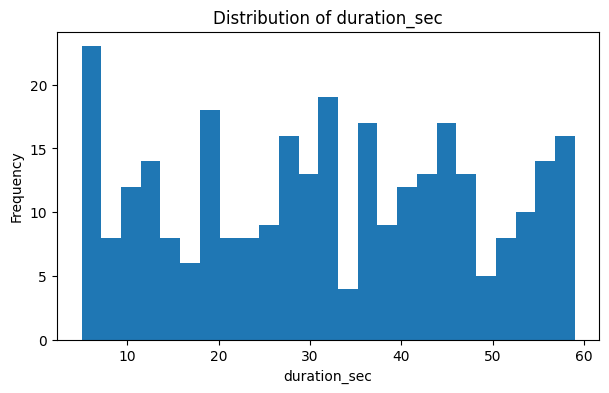

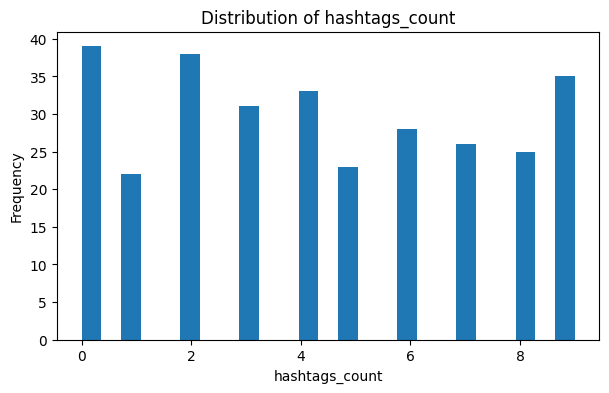

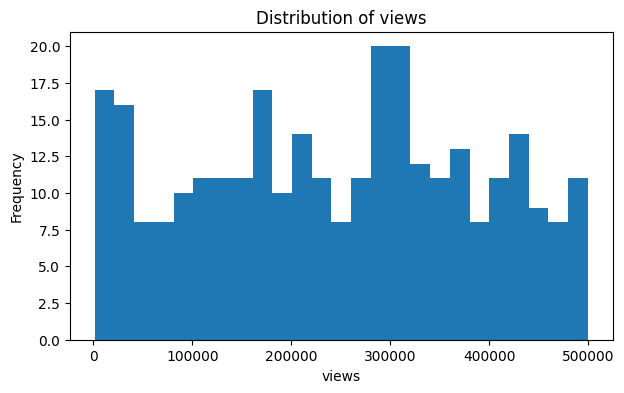

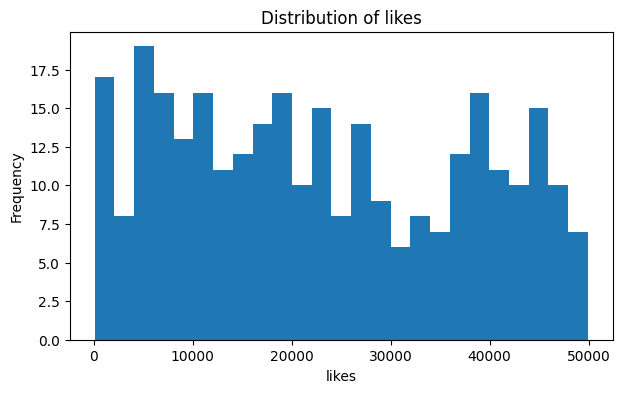

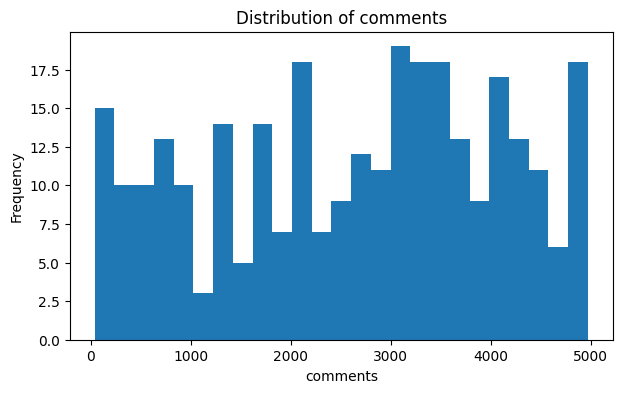

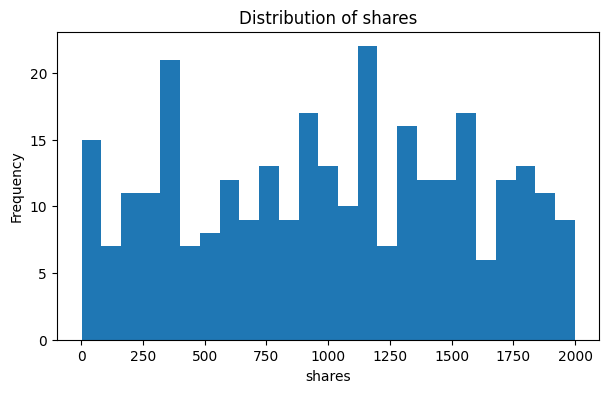

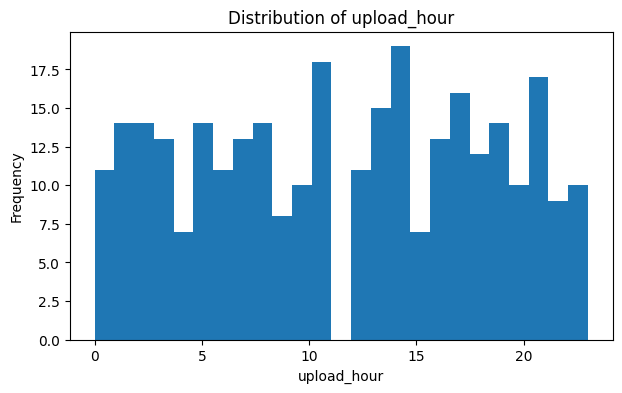

In [11]:
numeric_cols = df_clean.select_dtypes(include=np.number).columns

for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    plt.hist(df_clean[col], bins=25)
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {col}')
    plt.show()

In [12]:
category_views = df_clean.groupby('category')['views'].mean().sort_values(ascending=False)
category_views

,views
category,
Lifestyle,277479.952381
Comedy,271887.962264
Travel,246886.050000
Food,234776.947368
Education,224513.245283
Tech,223569.090909


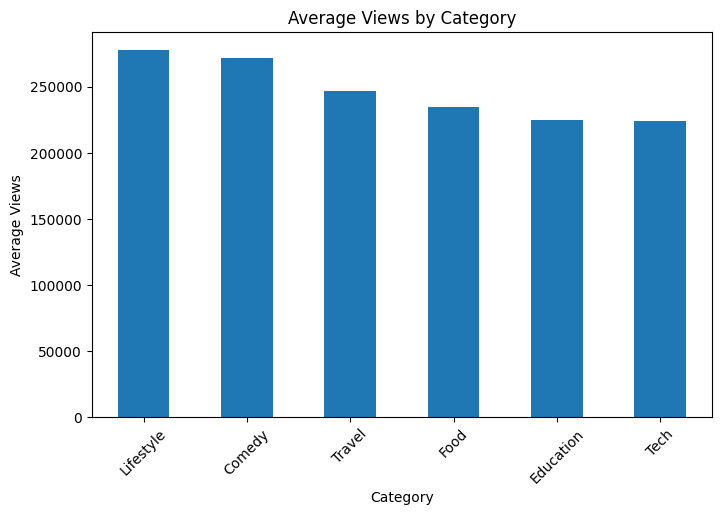

In [13]:
plt.figure(figsize=(8, 5))
category_views.plot(kind='bar')
plt.xlabel('Category')
plt.ylabel('Average Views')
plt.title('Average Views by Category')
plt.xticks(rotation=45)
plt.show()

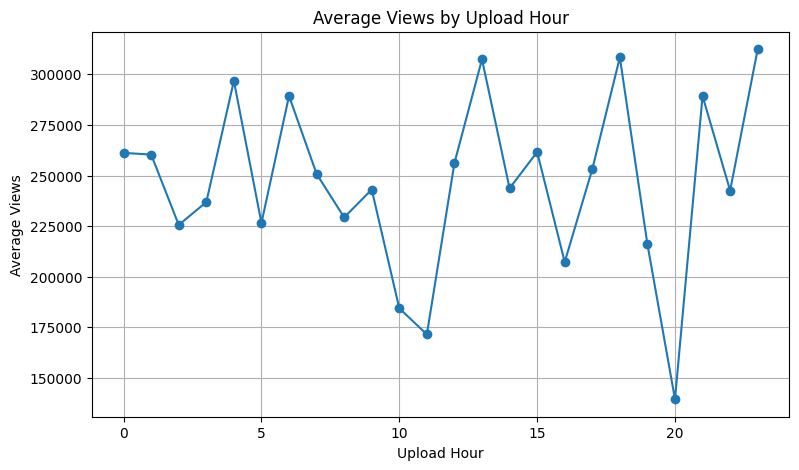

In [14]:
hour_views = df_clean.groupby('upload_hour')['views'].mean()

plt.figure(figsize=(9, 5))
hour_views.plot(kind='line', marker='o')
plt.xlabel('Upload Hour')
plt.ylabel('Average Views')
plt.title('Average Views by Upload Hour')
plt.grid(True)
plt.show()

In [15]:
corr = df_clean.select_dtypes(include=np.number).corr()
corr

,duration_sec,hashtags_count,views,likes,comments,shares,upload_hour
duration_sec,1.000000,-0.035128,0.074487,-0.052211,0.078740,0.071623,0.002692
hashtags_count,-0.035128,1.000000,0.010908,0.011884,-0.042305,0.078601,0.034368
views,0.074487,0.010908,1.000000,0.035115,0.069525,0.015937,0.018833
likes,-0.052211,0.011884,0.035115,1.000000,-0.034672,-0.037390,-0.014855
comments,0.078740,-0.042305,0.069525,-0.034672,1.000000,-0.001715,0.016920
shares,0.071623,0.078601,0.015937,-0.037390,-0.001715,1.000000,-0.027530
upload_hour,0.002692,0.034368,0.018833,-0.014855,0.016920,-0.027530,1.000000


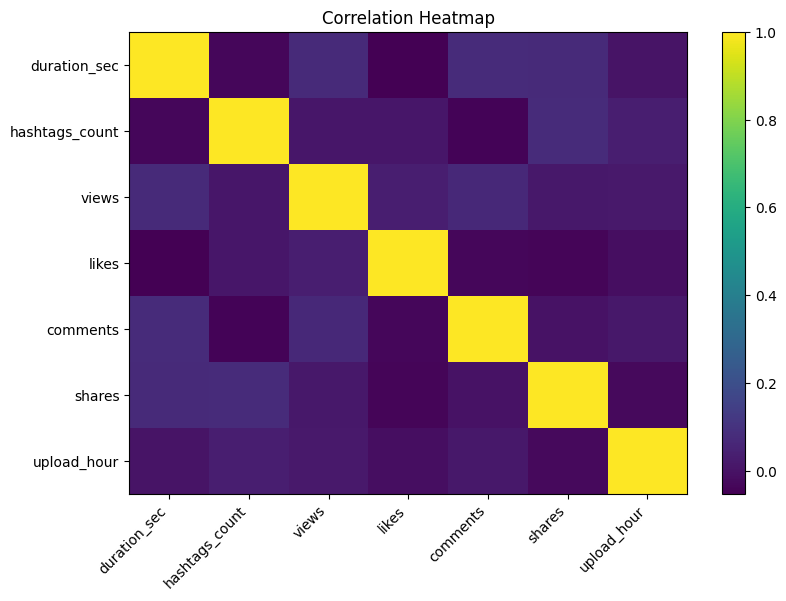

In [16]:
plt.figure(figsize=(9, 6))
plt.imshow(corr, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Correlation Heatmap')
plt.show()

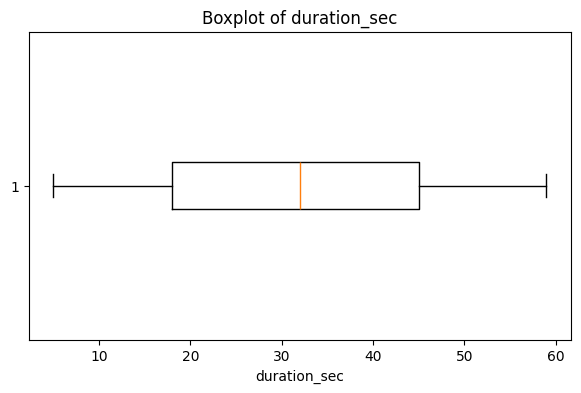

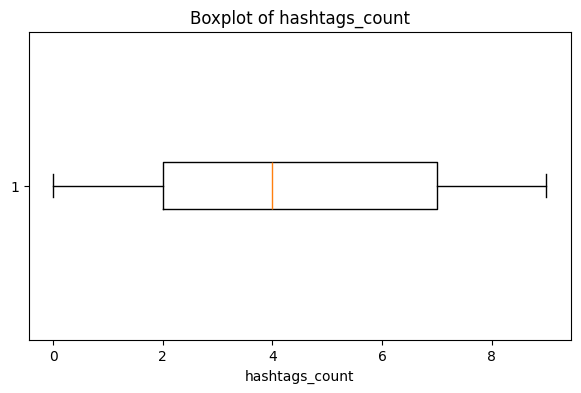

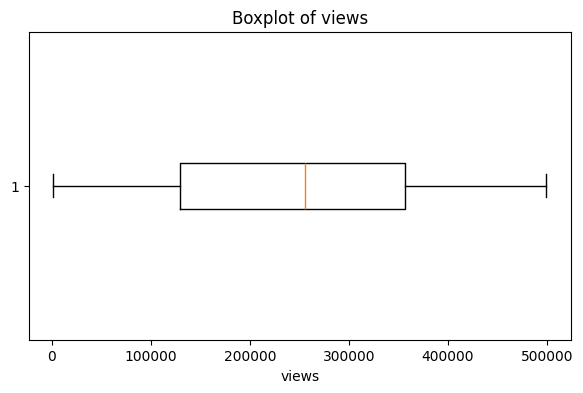

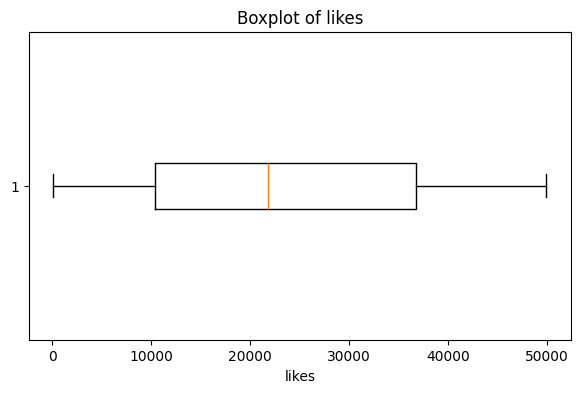

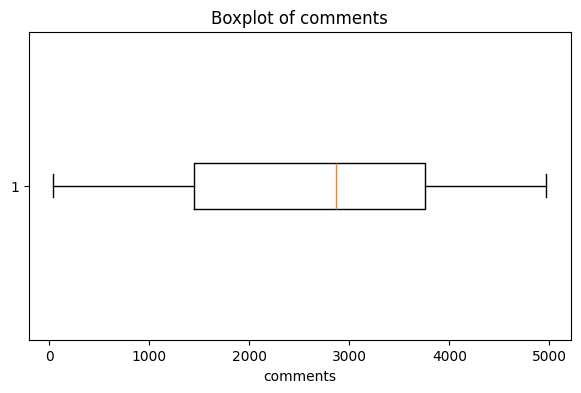

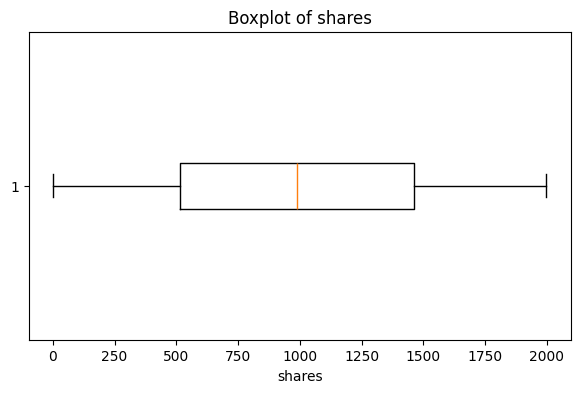

In [17]:
for col in ['duration_sec', 'hashtags_count', 'views', 'likes', 'comments', 'shares']:
    plt.figure(figsize=(7, 4))
    plt.boxplot(df_clean[col], vert=False)
    plt.xlabel(col)
    plt.title(f'Boxplot of {col}')
    plt.show()

In [18]:
df_fe = df_clean.copy()

df_fe['likes_per_view'] = df_fe['likes'] / (df_fe['views'] + 1)
df_fe['comments_per_view'] = df_fe['comments'] / (df_fe['views'] + 1)
df_fe['shares_per_view'] = df_fe['shares'] / (df_fe['views'] + 1)
df_fe['engagement_total'] = df_fe['likes'] + df_fe['comments'] + df_fe['shares']
df_fe['engagement_rate'] = df_fe['engagement_total'] / (df_fe['views'] + 1)

# Convert upload hour into time bucket
def time_bucket(hour):
    if 5 <= hour <= 11:
        return 'Morning'
    elif 12 <= hour <= 16:
        return 'Afternoon'
    elif 17 <= hour <= 21:
        return 'Evening'
    else:
        return 'Night'

df_fe['upload_time_bucket'] = df_fe['upload_hour'].apply(time_bucket)

df_fe.head()

,duration_sec,hashtags_count,views,likes,comments,shares,upload_hour,category,likes_per_view,comments_per_view,shares_per_view,engagement_total,engagement_rate,upload_time_bucket
0,43,9,198775,21933,3228,400,8,Tech,0.110340,0.016239,0.002012,25561,0.128592,Morning
1,56,2,290336,20063,3719,1942,16,Comedy,0.069102,0.012809,0.006689,25724,0.088600,Afternoon
2,33,6,264206,37032,3228,1817,7,Food,0.140163,0.012218,0.006877,42077,0.159258,Morning
3,19,9,85076,27269,2371,980,1,Lifestyle,0.320521,0.027869,0.011519,30620,0.359909,Night
4,47,8,90780,8041,2891,1109,23,Tech,0.088576,0.031846,0.012216,12041,0.132638,Night


In [19]:
X = df_fe.drop('views', axis=1)
y = df_fe['views']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Training Records:', X_train.shape[0])
print('Testing Records:', X_test.shape[0])

Training Records: 240
Testing Records: 60


In [20]:
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

print('Numeric Features:', numeric_features)
print('Categorical Features:', categorical_features)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

Numeric Features: ['duration_sec', 'hashtags_count', 'likes', 'comments', 'shares', 'upload_hour', 'likes_per_view', 'comments_per_view', 'shares_per_view', 'engagement_total', 'engagement_rate']
Categorical Features: ['category', 'upload_time_bucket']


In [21]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

results = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2 Score': r2
    })

results_df = pd.DataFrame(results).sort_values(by='R2 Score', ascending=False)
results_df

,Model,MAE,RMSE,R2 Score
5,Gradient Boosting,22020.302863,29517.907835,0.957465
4,Random Forest,24026.121667,32161.268349,0.949506
3,Decision Tree,35123.016667,45856.638755,0.897345
2,Lasso Regression,117077.228592,136277.502202,0.093386
0,Linear Regression,117077.355398,136277.598438,0.093384
1,Ridge Regression,116968.894672,136336.561316,0.092600


In [22]:
best_model_name = results_df.iloc[0]['Model']
best_model_name

'Gradient Boosting'

In [23]:
best_model = models[best_model_name]

best_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', best_model)
])

best_pipeline.fit(X_train, y_train)
y_pred = best_pipeline.predict(X_test)

print('Best Model:', best_model_name)
print('MAE:', round(mean_absolute_error(y_test, y_pred), 2))
print('RMSE:', round(np.sqrt(mean_squared_error(y_test, y_pred)), 2))
print('R2 Score:', round(r2_score(y_test, y_pred), 4))

Best Model: Gradient Boosting
MAE: 22020.3
RMSE: 29517.91
R2 Score: 0.9575


In [24]:
comparison_df = pd.DataFrame({
    'Actual Views': y_test.values,
    'Predicted Views': y_pred.round(0)
})
comparison_df.head(10)

,Actual Views,Predicted Views
0,1404,3410.0
1,486450,423294.0
2,384934,388661.0
3,389318,376772.0
4,300888,305823.0
5,429032,427632.0
6,309684,313527.0
7,424570,403051.0
8,153617,147688.0
9,321285,335606.0


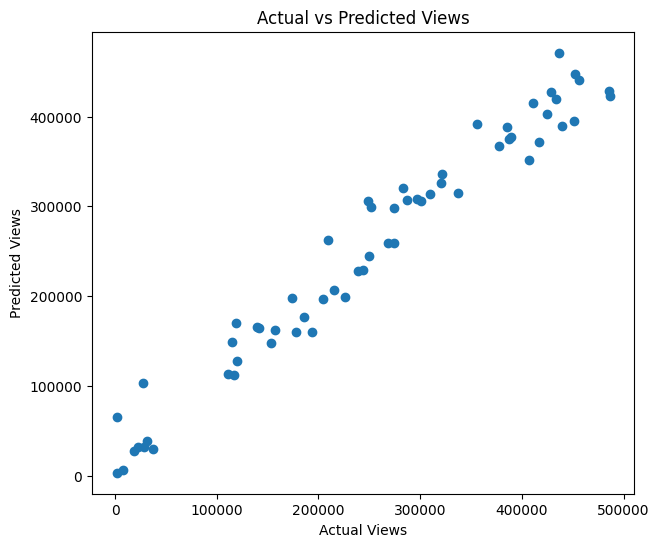

In [25]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Views')
plt.ylabel('Predicted Views')
plt.title('Actual vs Predicted Views')
plt.show()

,Feature,Importance
10,engagement_rate,0.436275
8,shares_per_view,0.278943
7,comments_per_view,0.155849
9,engagement_total,0.043763
4,shares,0.026329
3,comments,0.024898
6,likes_per_view,0.023614
2,likes,0.006796
0,duration_sec,0.001980
5,upload_hour,0.001116


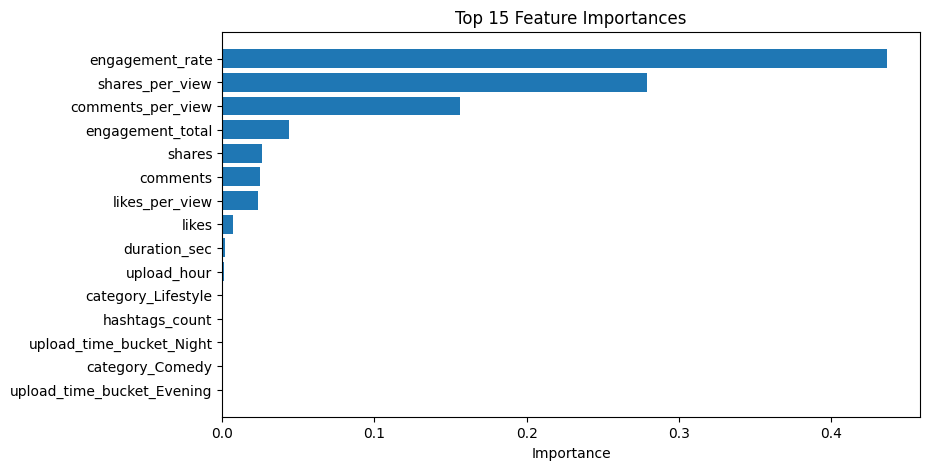

In [26]:
if best_model_name in ['Decision Tree', 'Random Forest', 'Gradient Boosting']:
    fitted_preprocessor = best_pipeline.named_steps['preprocessor']
    fitted_model = best_pipeline.named_steps['model']

    ohe = fitted_preprocessor.named_transformers_['cat'].named_steps['onehot']
    cat_feature_names = ohe.get_feature_names_out(categorical_features)
    feature_names = numeric_features + list(cat_feature_names)

    importances = fitted_model.feature_importances_
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    display(feature_importance_df.head(15))

    plt.figure(figsize=(9, 5))
    plt.barh(feature_importance_df.head(15)['Feature'][::-1],
             feature_importance_df.head(15)['Importance'][::-1])
    plt.xlabel('Importance')
    plt.title('Top 15 Feature Importances')
    plt.show()
else:
    print('Feature importance is not directly available for the selected model.')

In [27]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 5, 10],
    'model__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print('Best Parameters:', grid_search.best_params_)
print('Best CV R2 Score:', round(grid_search.best_score_, 4))

tuned_rf = grid_search.best_estimator_
tuned_pred = tuned_rf.predict(X_test)

print('Tuned RF Test MAE:', round(mean_absolute_error(y_test, tuned_pred), 2))
print('Tuned RF Test RMSE:', round(np.sqrt(mean_squared_error(y_test, tuned_pred)), 2))
print('Tuned RF Test R2:', round(r2_score(y_test, tuned_pred), 4))

Best Parameters: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best CV R2 Score: 0.8841
Tuned RF Test MAE: 24026.12
Tuned RF Test RMSE: 32161.27
Tuned RF Test R2: 0.9495


## 16. Business Questions and Answers

### 1. What factors influence views the most?
Engagement variables such as likes, shares, and comments are usually the strongest indicators of high views. If people interact with a Short, the platform is more likely to continue recommending it.

### 2. Does category matter?
Yes. Some categories may naturally attract more views because of broader audience interest or higher shareability. Category-wise average views help identify which content themes perform better.

### 3. Does upload time matter?
Upload hour can affect initial reach. If a video is uploaded when the audience is active, it may receive quicker engagement, which can improve visibility.

### 4. Why use machine learning for this problem?
Manual guessing is difficult because views depend on multiple factors together. A machine learning model can combine metadata and engagement signals to estimate expected performance more consistently.

### 5. How can creators use this model?
Creators can use the model to understand which content characteristics are linked with better reach and can plan upload timing, category focus, and engagement strategy accordingly.